* **Nama**: Rafi Iqbal Rendy Syachputra
* **NIM**: 3.34.23.3.19
* **Kelas**: IK-3D

Jobsheet 05: MENGUKUR KEMIRIPAN CITRA DAN
PENERAPANNYA DALAM PENGENALAN POLA

Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


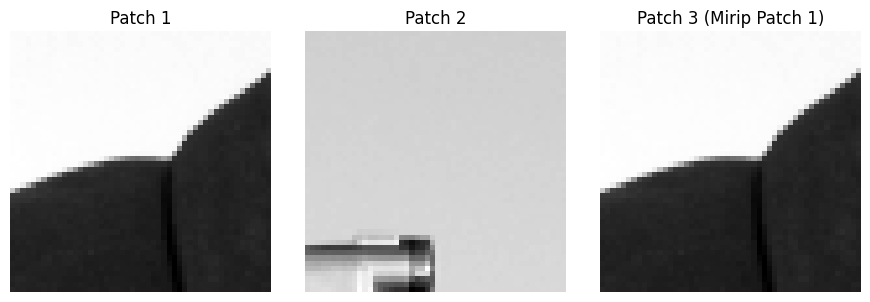

In [2]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1 # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1) # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

Praktikum 2. Menghitung Cosine Similarity (Histogram Warna)

Cosine Similarity (Astronaut vs Coffee): 0.8156
Cosine Similarity (Astronaut vs Astronaut): 1.0000
Cosine Similarity (Astronaut vs Downsampled): 1.0000


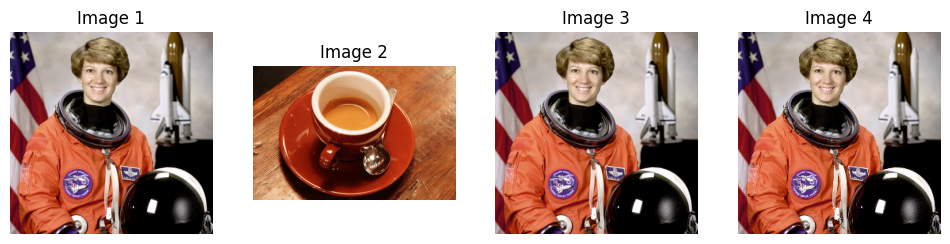

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat citra berwarna
image1 = data.astronaut()
image2 = data.coffee()
image3 = data.astronaut()
image4 = image1[::2, ::2, :] # Downsampled

# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity (Astronaut vs Coffee): {sim_12:.4f}")
print(f"Cosine Similarity (Astronaut vs Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity (Astronaut vs Downsampled): {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4'); axes[3].axis('off')
plt.show()

Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2960
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


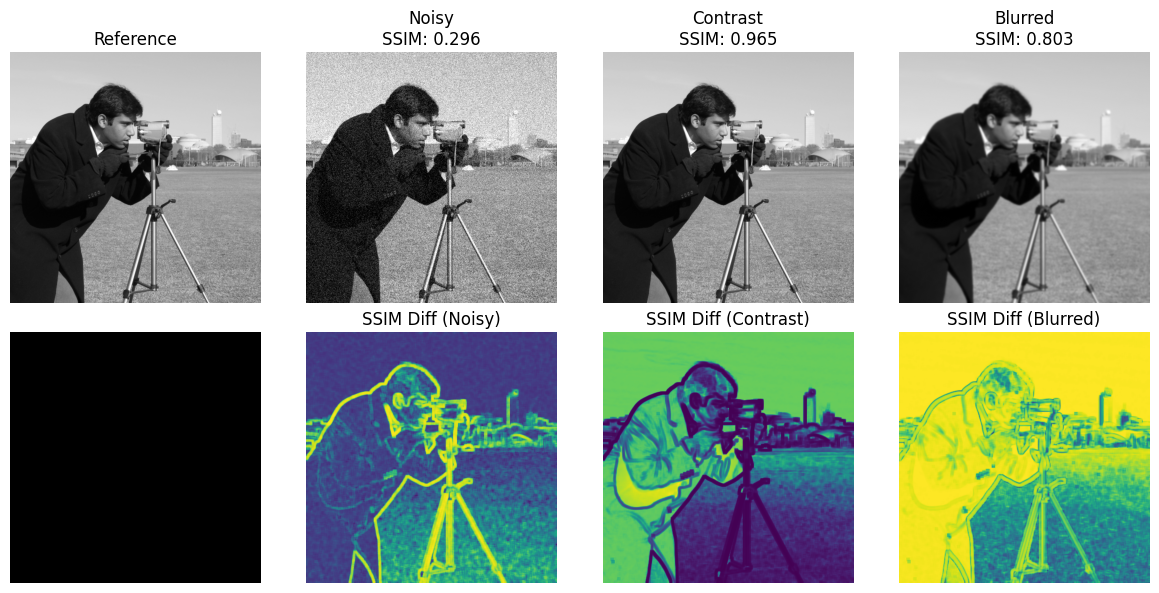

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.filters import gaussian
from skimage.util import random_noise

image_ref = img_as_float(data.camera())
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

data_range = image_ref.max() - image_ref.min()
ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 4. Tampilkan hasil SSIM dan citra perbedaan
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris 1: Citra Referensi dan yang terdistorsi
ax[0].imshow(image_ref, cmap='gray'); ax[0].set_title('Reference'); ax[0].axis('off')
ax[1].imshow(image_noisy, cmap='gray'); ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray'); ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); ax[3].axis('off')

# Baris 2: Peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray'); ax[4].set_title(''); ax[4].axis('off') # Placeholder
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('SSIM Diff (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Diff (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('SSIM Diff (Blurred)'); ax[7].axis('off')

plt.tight_layout()
plt.show()

Praktikum 4. Penerapan Template Matching

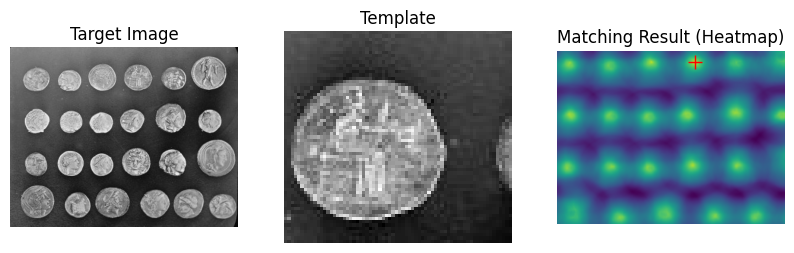

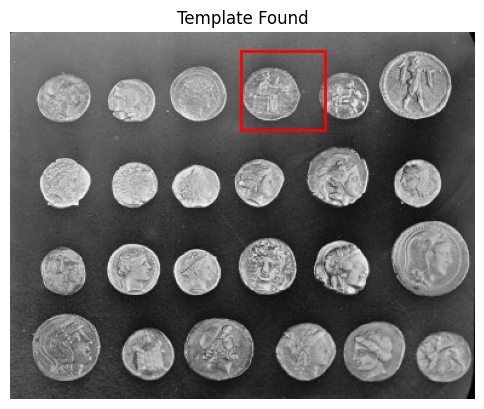

Template ditemukan di koordinat (x,y): (190, 15)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan ambil salah satu koin sebagai template
image = data.coins()
# Koordinat koin yang akan dijadikan template
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
# unravel_index mengubah indeks linear argmax ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1] # Koordinat (x, y) untuk plotting

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
# Tandai lokasi terbaik dengan tanda plus merah
ax[2].plot(x, y, 'r+', markersize=10)

# Menampilkan kotak di lokasi terbaik pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

Praktikum 5 :Simulasi Content-Based Image Retrieval (CBIR) Sederhana




Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


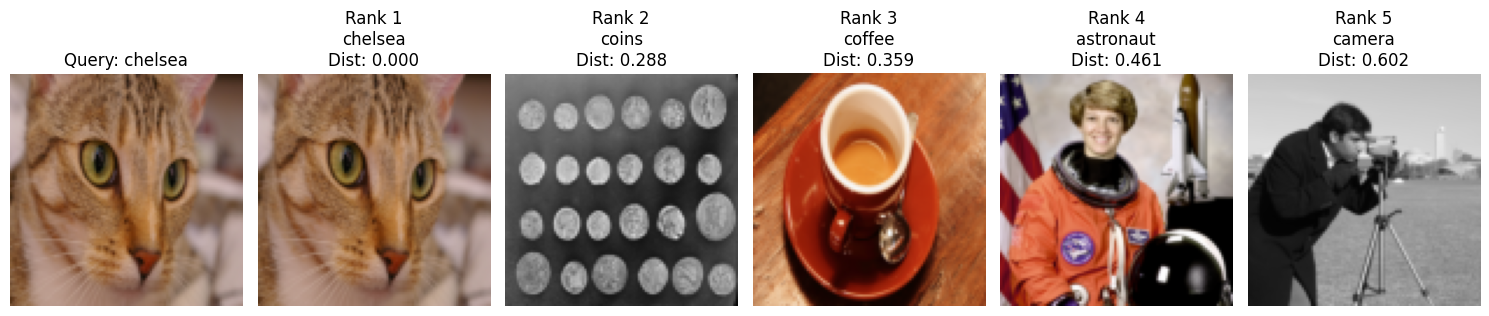

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram gabungan R, G, B
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi agar total luas histogram = 1
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    return hist_combined

# 1. Siapkan 'database' citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2: # Konversi grayscale ke RGB agar konsisten
            img = color.gray2rgb(img)
        # Resize semua gambar ke ukuran yang sama (100x100)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih 'chelsea' (kucing) sebagai citra query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 2. Hitung jarak Cosine antara query dan semua isi database
distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 3. Urutkan hasil berdasarkan jarak terkecil (paling mirip)
sorted_indices = np.argsort(distances)

# 4. Tampilkan hasil retrieval
num_results = len(database_images)
fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))

# Plot citra Query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    rank = i + 1
    ax = axes[rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

Penugasan 3: Fitur Berbeda untuk CBIR (Mean Color vs Histogram)

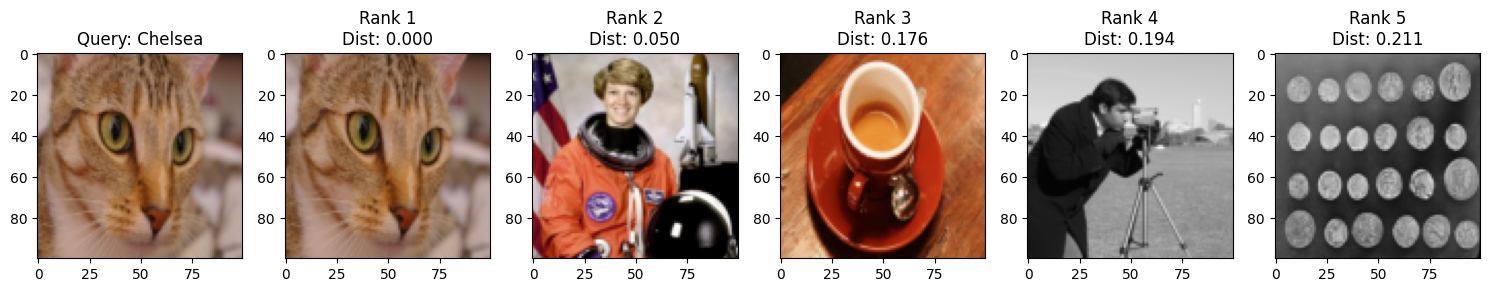

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, color
from scipy.spatial import distance

# 1. Siapkan Database dan Fungsi Fitur Baru (Mean RGB)
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
db_images = []
db_features = [] # Akan menyimpan vektor 3D [R_mean, G_mean, B_mean]

for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2: img = color.gray2rgb(img) # Pastikan RGB
    img_res = transform.resize(img, (100, 100))
    db_images.append(img_res)

    # HITUNG MEAN RGB (Vektor 3 Dimensi)
    mean_feat = np.mean(img_res, axis=(0, 1))
    db_features.append(mean_feat)

# 2. Pilih Query (Chelsea)
query_idx = 4 # Indeks chelsea
query_feat = db_features[query_idx]

# 3. Hitung Jarak Euclidean (L2)
l2_distances = [distance.euclidean(query_feat, f) for f in db_features]
sorted_idx = np.argsort(l2_distances)

# 4. Visualisasi (Hasil Retrieval)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(db_images[query_idx]); axes[0].set_title("Query: Chelsea")
for i, idx in enumerate(sorted_idx):
    axes[i+1].imshow(db_images[idx])
    axes[i+1].set_title(f"Rank {i+1}\nDist: {l2_distances[idx]:.3f}")
plt.tight_layout()
plt.show()

Penugasan 4: Template Matching Invariant

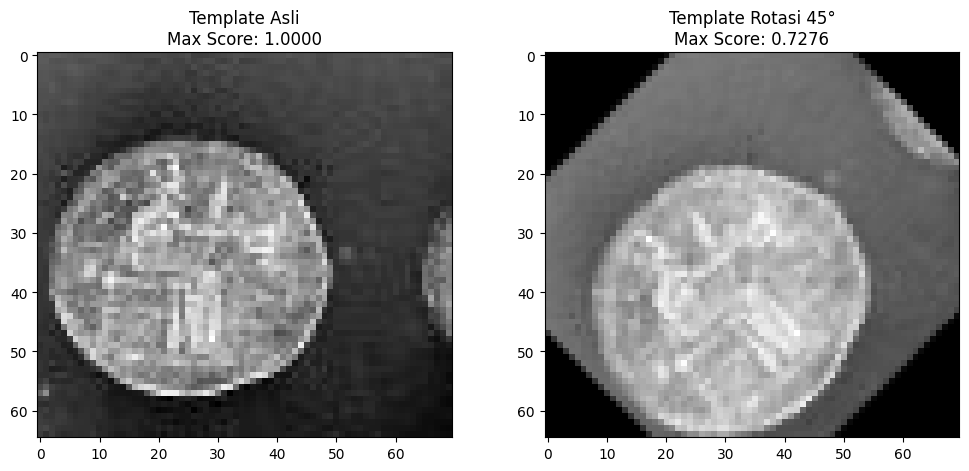

Hasil Analisis:
- Skor kecocokan turun dari 1.0000 menjadi 0.7276


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate

# 1. Gunakan data dari Praktikum 4
image = data.coins()
template = image[15:80, 190:260]

# 2. Modifikasi Template (Rotasi 45 Derajat)
template_rotated = rotate(template, angle=45, resize=False)

# 3. Jalankan Template Matching pada kedua versi
result_original = match_template(image, template)
result_rotated = match_template(image, template_rotated)

# 4. Cari skor tertinggi
score_orig = np.max(result_original)
score_rot = np.max(result_rotated)

# 5. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tampilan Template Asli vs Rotasi
axes[0].imshow(template, cmap='gray')
axes[0].set_title(f"Template Asli\nMax Score: {score_orig:.4f}")
axes[1].imshow(template_rotated, cmap='gray')
axes[1].set_title(f"Template Rotasi 45°\nMax Score: {score_rot:.4f}")

plt.show()

# Print Jawaban Analisis
print(f"Hasil Analisis:")
print(f"- Skor kecocokan turun dari {score_orig:.4f} menjadi {score_rot:.4f}")